In [ ]:
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import threading
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

In [ ]:
!pip install -q pyomo
!apt-get install -y -qq glpk-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.3 MB/s eta 0:00:00
Selecting previously unselected package libsuitesparseconfig5:amd64.
(Reading database ... 123620 files and directories currently installed.)
Preparing to unpack .../libsuitesparseconfig5_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libamd2:amd64.
Preparing to unpack .../libamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libcolamd2:amd64.
Preparing to unpack .../libcolamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libcolamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libglpk40:amd64.
Preparing to unpack .../libglpk40_5.0-1_amd64.deb ...
Unpacking libglpk40:amd64 (5.0-1) ...
Selecting previously unselected package

In [ ]:
!pip install -q pyomo
!apt-get install -y -qq glpk-utils

In [ ]:
def remove_outliers_iqr(df):

    numeric_cols = df.select_dtypes(include='number').columns
    # numeric_cols=['SalesValue']
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter out outliers for the current column
        df = df[~((df[col] < lower_bound) | (df[col] > upper_bound))]

    return df

In [ ]:
file_path='/content/D1_L1_Brand_L2_PPG.xlsx'
xls = pd.ExcelFile(file_path)


data_frames = []
for sheet_name in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet_name)


    data_frames.append(df)

In [ ]:
# from pyomo.environ import*
# import pandas as pd
# import numpy as np
# !apt-get install -y -qq coinor-cbc
# !wget -N -q "https://ampl.com/dl/open/bonmin/bonmin-linux64.zip"
# !unzip -o -q bonmin-linux64

In [ ]:
df_beans=data_frames[].copy()

In [ ]:
df1=df_beans[['Year','Month', 'Week','Volume','Brand','PPL','PPG','PPL_cann','PPL_Comp@Direct','PPL_Comp@Indirect','D1','D1_cann',
       'D1_Comp@Direct', 'D1_Comp@Indirect','Seasonality',
       'Trend','Up_Down_Index']].reset_index(drop=True)

In [ ]:
df1.fillna(0,inplace=True)

In [ ]:
df1.columns

Index(['Year', 'Month', 'Week', 'Volume', 'Brand', 'PPL', 'PPG', 'PPL_cann',
       'PPL_Comp@Direct', 'PPL_Comp@Indirect', 'D1', 'D1_cann',
       'D1_Comp@Direct', 'D1_Comp@Indirect', 'Seasonality', 'Trend',
       'Up_Down_Index'],
      dtype='object')

In [ ]:
df1['PPG'].unique()

array(['Small Multi'], dtype=object)

In [ ]:
df1['Brand'].unique()

array(['HEINZ Standard'], dtype=object)

In [ ]:
df_col = df1.loc[:, (df1 != 0).any(axis=0)]
df_col

,Year,Month,Week,Volume,Brand,PPL,PPG,PPL_cann,PPL_Comp@Indirect,D1,D1_cann,D1_Comp@Indirect,Seasonality,Trend,Up_Down_Index
0,2021,1,2,3921.270703,HEINZ Standard,3.071508,Small Multi,1.933118,1.028610,26.355994,84.463472,72.592178,8.425197e+07,1,2.250168
1,2021,1,3,3461.335676,HEINZ Standard,3.074615,Small Multi,1.933564,1.041033,26.415643,84.447423,69.760972,8.425197e+07,2,2.266550
2,2021,1,4,3395.916715,HEINZ Standard,3.075363,Small Multi,2.017236,1.067840,26.390015,86.892318,67.579750,8.425197e+07,3,2.219796
3,2021,1,5,3492.381491,HEINZ Standard,3.074105,Small Multi,2.051996,1.083692,26.038685,87.118169,67.627425,8.425197e+07,4,2.175764
4,2021,2,6,3392.484948,HEINZ Standard,3.076719,Small Multi,2.043497,1.082076,26.201819,88.074143,67.528508,7.639503e+07,5,2.171502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,2024,1,4,1772.778225,HEINZ Standard,5.322600,Small Multi,2.851976,1.661923,31.927881,90.697194,71.319289,8.425197e+07,160,2.174845
160,2024,2,5,1753.251252,HEINZ Standard,5.315826,Small Multi,2.857740,1.666190,31.596859,90.581013,70.614707,7.639503e+07,161,2.177309
161,2024,2,6,1817.785920,HEINZ Standard,5.337116,Small Multi,2.856014,1.583579,32.801778,89.381278,72.022431,7.639503e+07,162,2.174335
162,2024,2,7,1651.046687,HEINZ Standard,5.342928,Small Multi,2.866559,1.544563,31.654302,88.203383,72.633229,7.639503e+07,163,2.179272


In [ ]:
df_col.columns

Index(['Year', 'Month', 'Week', 'Volume', 'Brand', 'PPL', 'PPG', 'PPL_cann',
       'PPL_Comp@Indirect', 'D1', 'D1_cann', 'D1_Comp@Indirect', 'Seasonality',
       'Trend', 'Up_Down_Index'],
      dtype='object')

In [ ]:
print(df_col.dtypes)

Year                   int64
Month                  int64
Week                   int64
Volume               float64
Brand                 object
PPL                  float64
PPG                   object
PPL_cann             float64
PPL_Comp@Indirect    float64
D1                   float64
D1_cann              float64
D1_Comp@Indirect     float64
Seasonality          float64
Trend                  int64
Up_Down_Index        float64
dtype: object


In [ ]:

columns_to_plot=[ 'PPL', 'PPL_cann',
       'PPL_Comp@Indirect','D1', 'D1_cann', 'D1_Comp@Indirect', 'Seasonality',
       'Trend', 'Up_Down_Index']


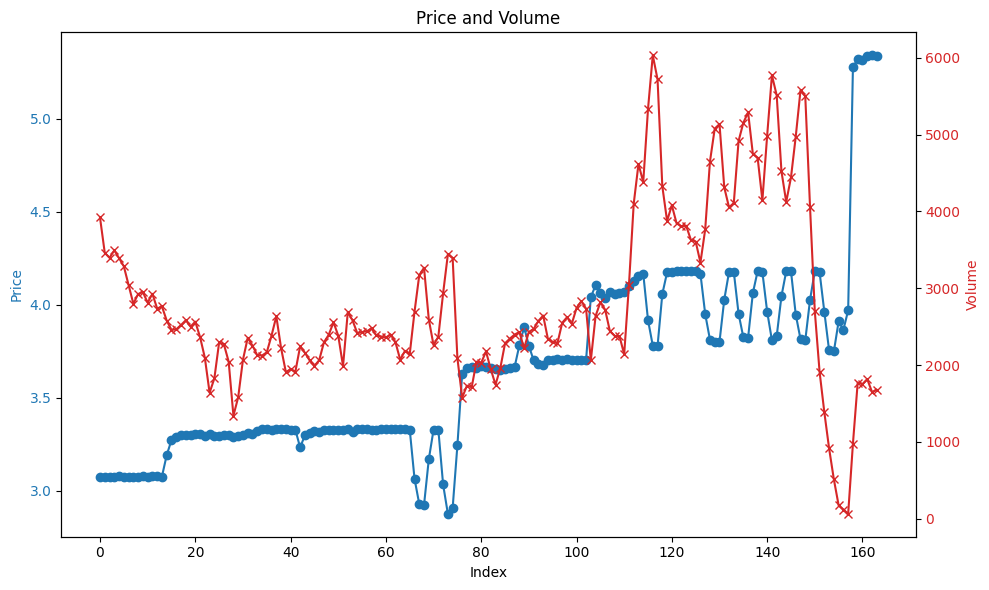

In [ ]:
import matplotlib.pyplot as plt

# Extract Price and Volume data
price = df_col['PPL']
volume = df_col['Volume']

# Create a figure with two y-axes for Price and Volume
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Price
ax1.set_xlabel('Index')
ax1.set_ylabel('Price', color='tab:blue')
ax1.plot(price, color='tab:blue', label='Price', marker='o')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis for Volume
ax2 = ax1.twinx()
ax2.set_ylabel('Volume', color='tab:red')
ax2.plot(volume, color='tab:red', label='Volume', marker='x')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Adding title and legend
plt.title('Price and Volume')
fig.tight_layout()
plt.show()


# Demand Curve

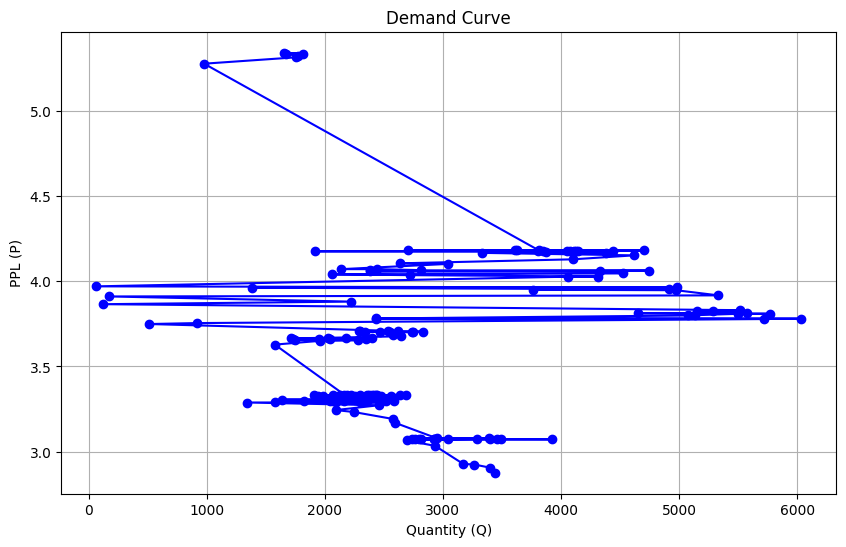

In [ ]:
import matplotlib.pyplot as plt

# Extract PPL and Volume data
PPL = df_col['PPL']
volume = df_col['Volume']

# Sort data for clearer demand curve visualization
sorted_data = df_col.sort_values(by='PPL')
sorted_PPL = sorted_data['PPL']
sorted_volume = sorted_data['Volume']

# Plotting the demand curve
plt.figure(figsize=(10, 6))
plt.plot(sorted_volume, sorted_PPL, marker='o', linestyle='-', color='b')

# Adding labels and title
plt.xlabel('Quantity (Q)')
plt.ylabel('PPL (P)')
plt.title('Demand Curve')
plt.grid(True)
plt.show()


# Smoothed Demand Curve

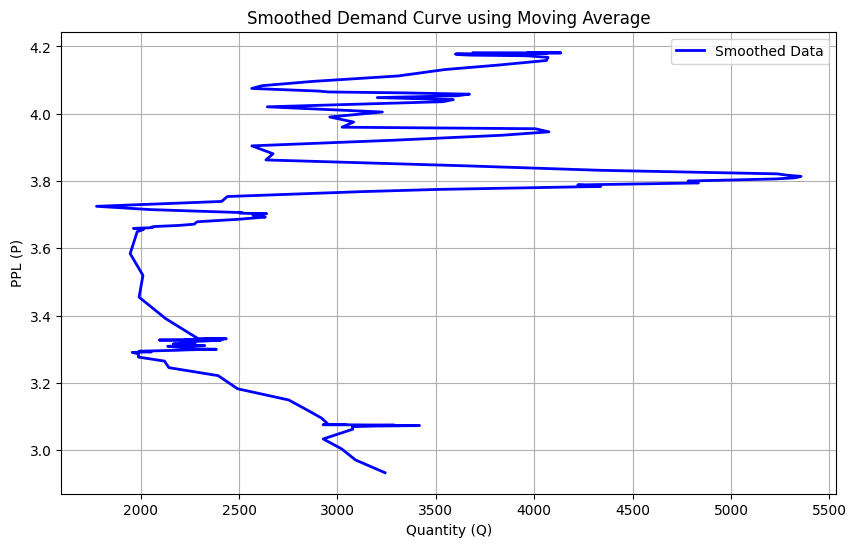

In [ ]:
import numpy as np
from scipy.stats import zscore

# Remove outliers based on Z-score threshold (e.g., Z-score > 3 is considered an outlier)
df_cleaned = df_col[(np.abs(zscore(df_col['PPL'])) < 3) & (np.abs(zscore(df_col['Volume'])) < 3)]
# Sort by PPL for demand visualization
df_sorted = df_cleaned.sort_values(by='PPL')
price_smoothed = df_sorted['PPL'].rolling(window=5).mean()
volume_smoothed = df_sorted['Volume'].rolling(window=5).mean()

# Plotting the smoothed demand curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(volume_smoothed, price_smoothed, 'b-', label='Smoothed Data', linewidth=2)

# Adding labels and title
plt.xlabel('Quantity (Q)')
plt.ylabel('PPL (P)')
plt.title('Smoothed Demand Curve using Moving Average')
plt.grid(True)
plt.legend()
plt.show()


# Polynomial Regression Fit

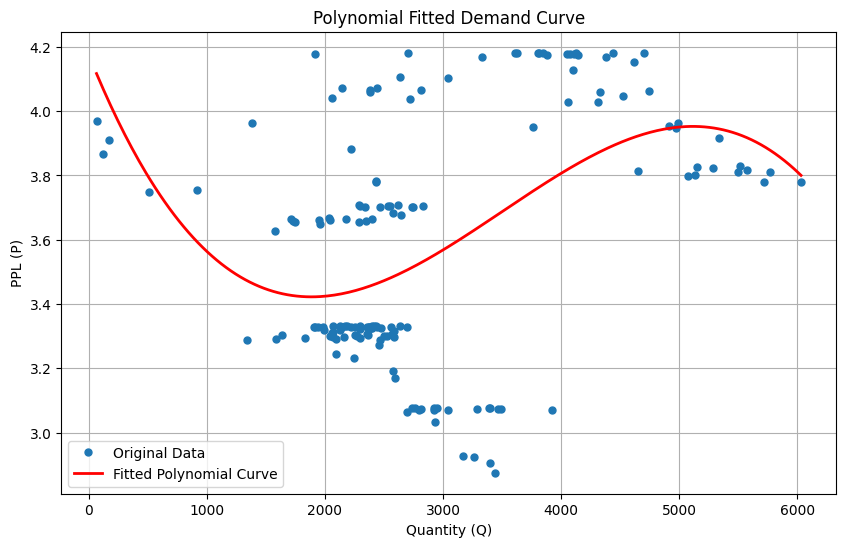

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial

# Sort data
df_sorted = df_cleaned.sort_values(by='PPL')
sorted_volume = df_sorted['Volume']
sorted_price = df_sorted['PPL']

# Fit a polynomial of degree 3
coefs = Polynomial.fit(sorted_volume, sorted_price, deg=3).convert().coef

# Generate the polynomial fit
volume_new = np.linspace(sorted_volume.min(), sorted_volume.max(), 300)
price_fit = np.polyval(coefs[::-1], volume_new)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(sorted_volume, sorted_price, 'o', label='Original Data', markersize=5)
plt.plot(volume_new, price_fit, '-', color='r', label='Fitted Polynomial Curve', linewidth=2)

plt.xlabel('Quantity (Q)')
plt.ylabel('PPL (P)')
plt.title('Polynomial Fitted Demand Curve')
plt.legend()
plt.grid(True)
plt.show()


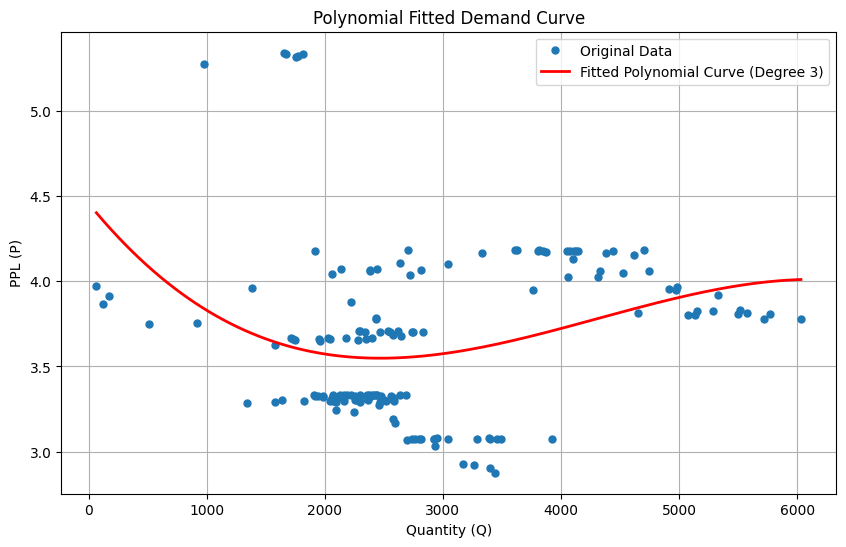

Polynomial Coefficients (from highest to lowest degree):
[-1.86943551e-11  2.41441820e-07 -8.50201626e-04  4.45705299e+00]
Polynomial Equation: PPL = 4.4571*x^0 + -0.0009*x^1 + 0.0000*x^2 + -0.0000*x^3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial

# Sort data for demand visualization
df_sorted = df_col.sort_values(by='PPL')
sorted_volume = df_sorted['Volume']
sorted_price = df_sorted['PPL']

# Fit a polynomial of degree 3 (you can change this degree as needed)
degree = 3
coefs = Polynomial.fit(sorted_volume, sorted_price, deg=degree).convert().coef

# Generate the polynomial fit
volume_new = np.linspace(sorted_volume.min(), sorted_volume.max(), 300)
price_fit = np.polyval(coefs[::-1], volume_new)

# Plotting the fitted polynomial curve
plt.figure(figsize=(10, 6))
plt.plot(sorted_volume, sorted_price, 'o', label='Original Data', markersize=5)
plt.plot(volume_new, price_fit, '-', color='r', label=f'Fitted Polynomial Curve (Degree {degree})', linewidth=2)

# Adding labels and title
plt.xlabel('Quantity (Q)')
plt.ylabel('PPL (P)')
plt.title('Polynomial Fitted Demand Curve')
plt.legend()
plt.grid(True)
plt.show()

# Display the polynomial coefficients
print("Polynomial Coefficients (from highest to lowest degree):")
print(coefs[::-1])  # Print in descending order

# Display the polynomial equation
polynomial_eq = " + ".join([f"{coef:.4f}*x^{i}" for i, coef in enumerate(coefs)])
print(f"Polynomial Equation: PPL = {polynomial_eq}")


In [ ]:
def predict(x,w):
    return np.dot(x,w)

In [ ]:
def obj_function(x,w,y,lamda):
    y_pred=predict(x.T,w)
    return np.sum((y-y_pred)**2)+lamda*np.sum(w**2)



In [ ]:
df_col['PPL_square']=df_col['PPL']**2
df_col=remove_outliers_iqr(df_col)
df_col

,Year,Month,Week,Volume,Brand,PPL,PPG,PPL_cann,PPL_Comp@Indirect,D1,D1_cann,D1_Comp@Indirect,Seasonality,Trend,Up_Down_Index,PPL_square
4,2021,2,6,3392.484948,HEINZ Standard,3.076719,Small Multi,2.043497,1.082076,26.201819,88.074143,67.528508,7.639503e+07,5,2.171502,9.466201
5,2021,2,7,3285.903144,HEINZ Standard,3.073817,Small Multi,1.975743,1.046937,26.128469,85.894698,71.728178,7.639503e+07,6,2.207861,9.448350
6,2021,2,8,3040.823356,HEINZ Standard,3.070904,Small Multi,1.930054,1.027256,25.930198,83.287112,72.898310,7.639503e+07,7,2.242242,9.430453
7,2021,2,9,2798.458017,HEINZ Standard,3.071396,Small Multi,1.935147,1.030376,26.071493,83.462161,72.839921,7.639503e+07,8,2.247091,9.433472
8,2021,3,10,2924.196851,HEINZ Standard,3.071698,Small Multi,1.994403,1.078999,26.204290,86.988987,70.189620,5.659984e+07,9,2.238805,9.435330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,2022,12,52,2734.968392,HEINZ Standard,3.702101,Small Multi,2.824517,1.607947,20.859523,90.494629,73.463069,6.620043e+07,103,2.193242,13.705553
103,2022,12,53,2061.411052,HEINZ Standard,4.040791,Small Multi,3.455913,1.606743,20.549498,87.088149,73.160146,6.620043e+07,104,2.144063,16.327995
109,2023,2,6,2378.280231,HEINZ Standard,4.064910,Small Multi,3.305886,1.563293,20.632886,87.537113,77.113202,7.639503e+07,110,2.199298,16.523497
110,2023,2,7,2140.977148,HEINZ Standard,4.071595,Small Multi,3.259782,1.567479,20.250713,87.100842,75.331399,7.639503e+07,111,2.210133,16.577883


In [ ]:
df_col.columns

Index(['Year', 'Month', 'Week', 'Volume', 'Brand', 'PPL', 'PPG', 'PPL_cann',
       'PPL_Comp@Indirect', 'D1', 'D1_cann', 'D1_Comp@Indirect', 'Seasonality',
       'Trend', 'Up_Down_Index', 'PPL_square'],
      dtype='object')

In [ ]:
X=df_col[['PPL', 'PPL_cann', 'PPL_Comp@Indirect','D1','D1_cann',
        'D1_Comp@Indirect', 'Seasonality', 'Trend',
       'Up_Down_Index']]

Y=np.array(df_col['Volume'])
X=np.concatenate([np.ones((X.shape[0],1)),X],axis=1)
X

array([[1.00000000e+00, 3.07671916e+00, 2.04349742e+00, 1.08207623e+00,
        2.62018191e+01, 8.80741428e+01, 6.75285076e+01, 7.63950304e+07,
        5.00000000e+00, 2.17150223e+00],
       [1.00000000e+00, 3.07381688e+00, 1.97574343e+00, 1.04693730e+00,
        2.61284692e+01, 8.58946980e+01, 7.17281777e+01, 7.63950304e+07,
        6.00000000e+00, 2.20786094e+00],
       [1.00000000e+00, 3.07090420e+00, 1.93005374e+00, 1.02725570e+00,
        2.59301983e+01, 8.32871116e+01, 7.28983099e+01, 7.63950304e+07,
        7.00000000e+00, 2.24224219e+00],
       [1.00000000e+00, 3.07139571e+00, 1.93514729e+00, 1.03037605e+00,
        2.60714930e+01, 8.34621611e+01, 7.28399207e+01, 7.63950304e+07,
        8.00000000e+00, 2.24709072e+00],
       [1.00000000e+00, 3.07169815e+00, 1.99440274e+00, 1.07899862e+00,
        2.62042898e+01, 8.69889867e+01, 7.01896197e+01, 5.65998399e+07,
        9.00000000e+00, 2.23880496e+00],
       [1.00000000e+00, 3.07726773e+00, 2.01501764e+00, 1.11788489e+00,
   

In [ ]:
# # Add a bias column (a column of ones) to X
# X = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

# # Alternatively, you could add it directly to a DataFrame
# X = pd.concat([pd.Series(np.ones(X.shape[0]), name='Bias'), X], axis=1)
X=np.concatenate([np.ones((X.shape[0],1)),X],axis=1)
X



array([[1.00000000e+00, 1.00000000e+00, 3.07671916e+00, ...,
        7.63950304e+07, 5.00000000e+00, 2.17150223e+00],
       [1.00000000e+00, 1.00000000e+00, 3.07381688e+00, ...,
        7.63950304e+07, 6.00000000e+00, 2.20786094e+00],
       [1.00000000e+00, 1.00000000e+00, 3.07090420e+00, ...,
        7.63950304e+07, 7.00000000e+00, 2.24224219e+00],
       ...,
       [1.00000000e+00, 1.00000000e+00, 4.06491043e+00, ...,
        7.63950304e+07, 1.10000000e+02, 2.19929825e+00],
       [1.00000000e+00, 1.00000000e+00, 4.07159471e+00, ...,
        7.63950304e+07, 1.11000000e+02, 2.21013299e+00],
       [1.00000000e+00, 1.00000000e+00, 3.96231808e+00, ...,
        6.62004314e+07, 1.53000000e+02, 2.19870547e+00]])

In [ ]:
# Optimize
initial_params=np.zeros(X.shape[1])
lamda=0
result_prev = minimize(
    obj_function,
    initial_params,
    args=(X.T, Y, lamda ),
    method='SLSQP'
)

# Extract optimized parameters
W_opt = result_prev.x
y_pred=predict(X,W_opt)
y_pred


In [ ]:
W_opt

array([ 7.52226932e+06,  9.49880906e+06,  9.04004437e+07,  2.05527392e+08,
        3.30253707e+07, -1.44099092e+07, -8.46952606e+07,  9.91024533e+07,
       -5.12907163e+00, -5.21335757e+06,  1.71954789e+08])

In [ ]:
y_pred=predict(X,W_opt)
y_pred

array([-4.38401180e+08,  1.49132585e+08,  4.79197712e+08,  4.53364019e+08,
       -1.20177268e+06, -2.36057190e+08, -1.88895986e+08,  1.62513410e+08,
        3.86188718e+08,  3.34296782e+08, -1.58922702e+08, -4.56747402e+08,
       -4.42683038e+08,  1.77218280e+08,  3.43894161e+08,  3.75067815e+08,
       -7.77547524e+07, -4.20732320e+08, -1.90077641e+08,  4.18657770e+08,
        4.53842862e+08,  3.18174572e+08,  2.58708926e+08, -2.70813681e+08,
       -3.16753441e+08,  2.48280526e+08,  5.47574671e+08,  3.50702465e+08,
       -1.38165449e+07, -3.18969697e+08, -3.31123541e+08, -1.57245254e+07,
        2.15589831e+08, -2.20758442e+07, -1.65921837e+07,  1.78213617e+08,
        1.55803402e+08, -3.79752087e+07, -1.42471885e+07, -2.34651582e+08,
        7.66783595e+07,  2.89836456e+08,  2.00170403e+08,  1.20745865e+08,
       -4.40205453e+08, -7.21736792e+08, -7.49997669e+08, -6.51971420e+07,
        2.19847736e+08,  2.12768403e+08, -1.45743878e+08, -4.43851053e+08,
       -4.64892040e+08, -

In [ ]:
mean_absolute_percentage_error(Y,y_pred)

117935.81369958245

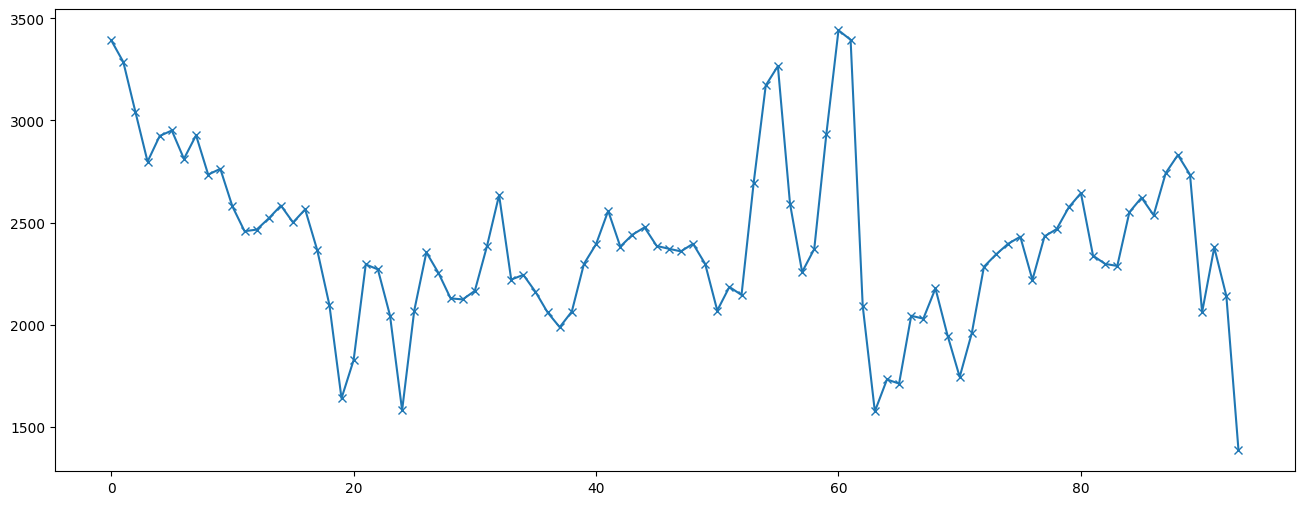

In [ ]:
x_value = np.arange(len(Y))
plt.figure(figsize=(16, 6))
plt.plot(x_value, Y, label='Original Values', marker='x')

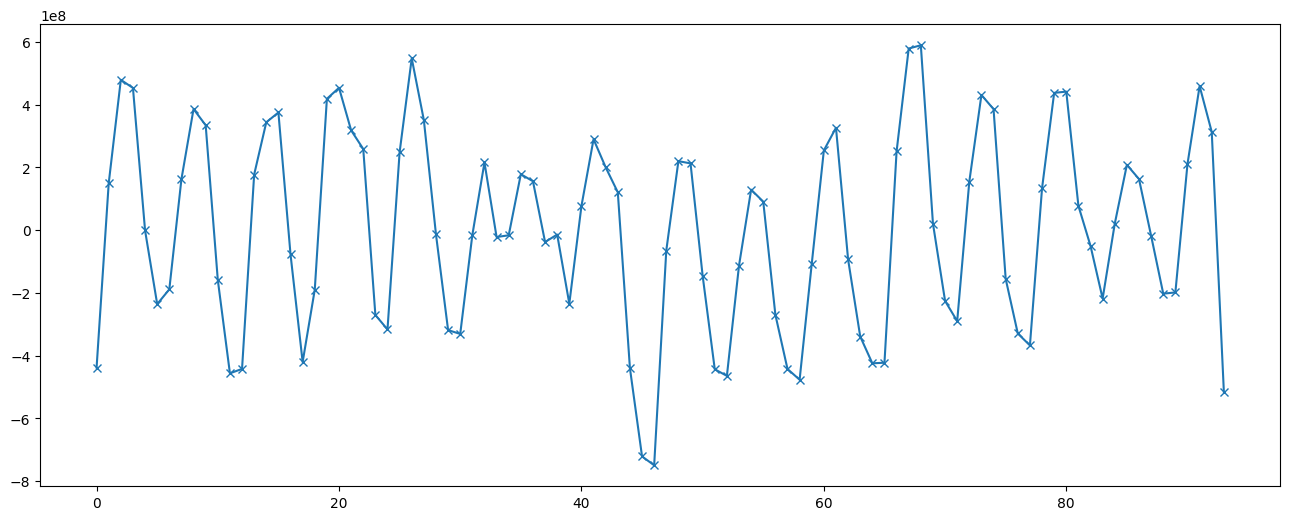

In [ ]:
x_value = np.arange(len(Y))
plt.figure(figsize=(16, 6))
plt.plot(x_value, y_pred, label='Predicted Values', marker='x')

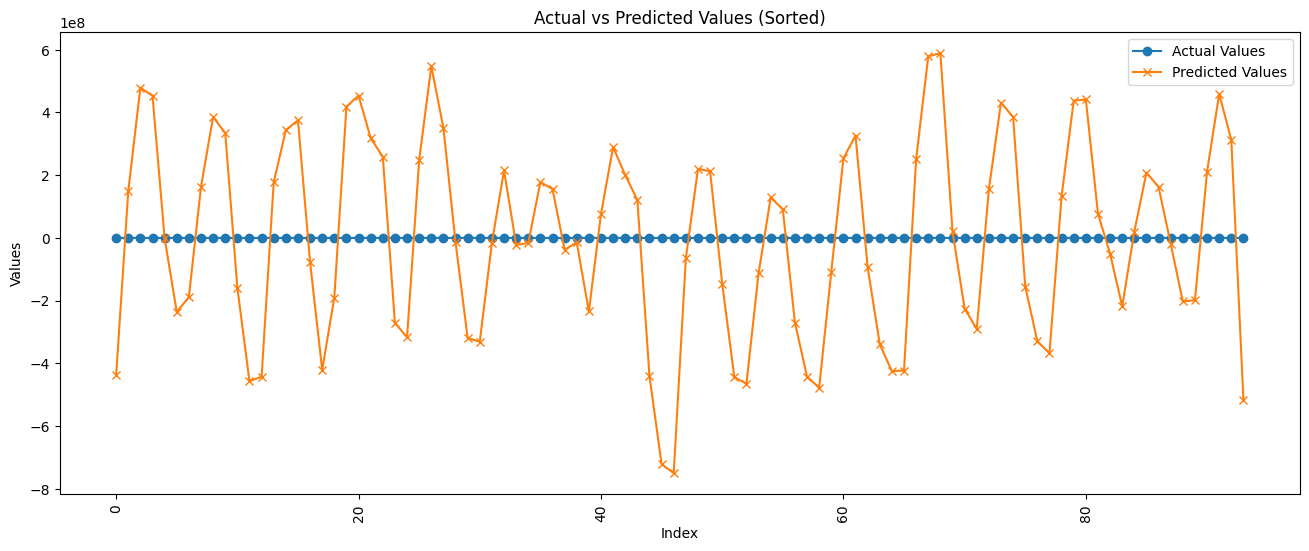

In [ ]:
plt.figure(figsize=(16, 6))
x_value = np.arange(len(Y))
plt.plot(x_value, Y, label='Actual Values', marker='o')
plt.plot(x_value, y_pred, label='Predicted Values', marker='x')

# Adding title and labels
plt.title('Actual vs Predicted Values (Sorted)')
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation = 90)
plt.legend()
plt.show()

In [ ]:
# # Install required dependencies
# !apt-get install -y -qq wget gfortran git
# !apt-get install -y -qq build-essential pkg-config liblapack-dev libblas-dev libmetis-dev

# # Download Ipopt source
# !wget -q https://www.coin-or.org/download/source/Ipopt/Ipopt-3.12.13.tgz

# # Extract Ipopt source
# !tar xzf Ipopt-3.12.13.tgz

# # Install third-party libraries required by Ipopt
# !wget -q https://www.coin-or.org/download/source/ThirdParty/HSL/ThirdParty-HSL-2014.01.17.tgz
# !tar xzf ThirdParty-HSL-2014.01.17.tgz
# !mv ThirdParty-HSL-2014.01.17 Ipopt-3.12.13/ThirdParty/HSL

# # Compile and install Ipopt
# !cd Ipopt-3.12.13 && ./configure && make && make install

# # Add Ipopt binary path to the system PATH
# !export PATH="/usr/local/bin:$PATH"


In [ ]:


# # Check if ipopt is available
# ipopt_available = SolverFactory('ipopt').available()
# print(f"Ipopt is available: {ipopt_available}")

In [ ]:
# from pyomo.environ import SolverFactory

# # Check if ipopt is available
# ipopt_available = SolverFactory('ipopt').available()
# print(f"Ipopt is available: {ipopt_available}")

In [ ]:
# import pyomo.environ as pyomo
# import numpy as np
# import pandas as pd
# from pyomo.opt import SolverFactory
# import matplotlib.pyplot as plt

# # Data preparation (assuming df_encoded is already loaded and processed)
# df_encoded['PPL_square'] = df_encoded['PPL']**2
# X = df_encoded[['PPL', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect',
#                 'Seasonality', 'Trend', 'Up_Down_Index', 'Brand_Private Label Std']]
# Y = np.array(df_encoded['Volume'])

# # Define model
# model = pyomo.ConcreteModel()

# # Set number of parameters
# n_features = X.shape[1]

# # Define decision variables (w for weights)
# model.w = pyomo.Var(range(n_features), domain=pyomo.Reals, initialize=0)

# # Lambda for regularization
# lamda = 0.01

# # Define the objective function (minimize squared error + regularization term)
# def obj_function(model):
#     y_pred = sum(model.w[i] * X.iloc[:, i].values for i in range(n_features))
#     return sum((Y[i] - y_pred[i])**2 for i in range(len(Y))) + lamda * sum(model.w[i]**2 for i in range(n_features))

# model.obj = pyomo.Objective(rule=obj_function, sense=pyomo.minimize)

# # Solver
# solver = SolverFactory('ipopt')  # or 'glpk', 'cbc', 'scipy'
# result = solver.solve(model, tee=True)

# # Extract optimized weights
# W_opt = np.array([pyomo.value(model.w[i]) for i in range(n_features)])

# # Predict using optimized weights
# y_pred = np.dot(X, W_opt)

# # Plot Actual vs Predicted Values
# plt.figure(figsize=(16, 6))
# x_value = np.arange(len(Y))
# plt.plot(x_value, Y, label='Actual Values', marker='o')
# plt.plot(x_value, y_pred, label='Predicted Values', marker='x')

# # Adding title and labels
# plt.title('Actual vs Predicted Values (Sorted)')
# plt.xlabel('Index')
# plt.ylabel('Values')
# plt.xticks(rotation=90)
# plt.legend()
# plt.show()

# # Calculate Mean Absolute Percentage Error
# mape = np.mean(np.abs((Y - y_pred) / Y)) * 100
# print(f'MAPE: {mape}%')


# Above complete code

In [ ]:
# def predict(x,w):
#     return np.dot(x,w)
# def obj_function(x,w,y,lamda):
#     y_pred=predict(x.T,w)
#     return np.sum((y-y_pred)**2)+lamda*np.sum(w**2)
# df_encoded['PPL_square']=df_encoded['PPL']**2
# X=df_encoded[['PPL', 'PPL_cann',
#        'PPL_Comp@Direct', 'PPL_Comp@Indirect', 'Seasonality', 'Trend',
#        'Up_Down_Index', 'Brand_BRANSTON']]
# Y=np.array(df_encoded['Volume'])
# # Optimize
# initial_params=np.zeros(X.shape[1])
# lamda=0.01
# result_prev = minimize(
#     obj_function,
#     initial_params,
#     args=(X.T, Y, lamda ),
#     method='SLSQP'
# )

# # Extract optimized parameters
# W_opt = result_prev.x
# y_pred=predict(X,W_opt)
# y_pred
# mean_absolute_percentage_error(Y,y_pred)
# plt.figure(figsize=(16, 6))
# x_value = np.arange(len(Y))
# plt.plot(x_value, Y, label='Actual Values', marker='o')
# plt.plot(x_value, y_pred, label='Predicted Values', marker='x')

# # Adding title and labels
# plt.title('Actual vs Predicted Values (Sorted)')
# plt.xlabel('Index')
# plt.ylabel('Values')
# plt.xticks(rotation = 90)
# plt.legend()
# plt.show()

# Non Linear:


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
mape_dict={}
for i in range(1,9):
# Generate polynomial features
  poly = PolynomialFeatures(degree=i)
  X_poly = poly.fit_transform(X)

  # Fit a linear regression model
  model = LinearRegression()
  model.fit(X_poly, Y)

  # Make predictions
  y_pred = model.predict(X_poly)

  # Calculate MAPE
  mape = mean_absolute_percentage_error(Y, y_pred)
  mape_dict[i]=mape
  # print('MAPE:', mape * 100, '%')




In [ ]:
mape_dict

{1: 0.05867343632028188,
 2: 0.04686956015551705,
 3: 0.05052156622104427,
 4: 0.07031291664185146,
 5: 0.07023780169276148,
 6: 0.05415662662590708,
 7: 0.0528434819861929,
 8: 0.06142955011714223}

In [ ]:
# Generate polynomial features
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

# Fit a linear regression model
model = LinearRegression()
model.fit(X_poly, Y)

# Make predictions
y_pred = model.predict(X_poly)

# Calculate MAPE
mape = mean_absolute_percentage_error(Y, y_pred)
mape_dict[i]=mape
print('MAPE:', mape * 100, '%')

MAPE: 5.052156622104427 %


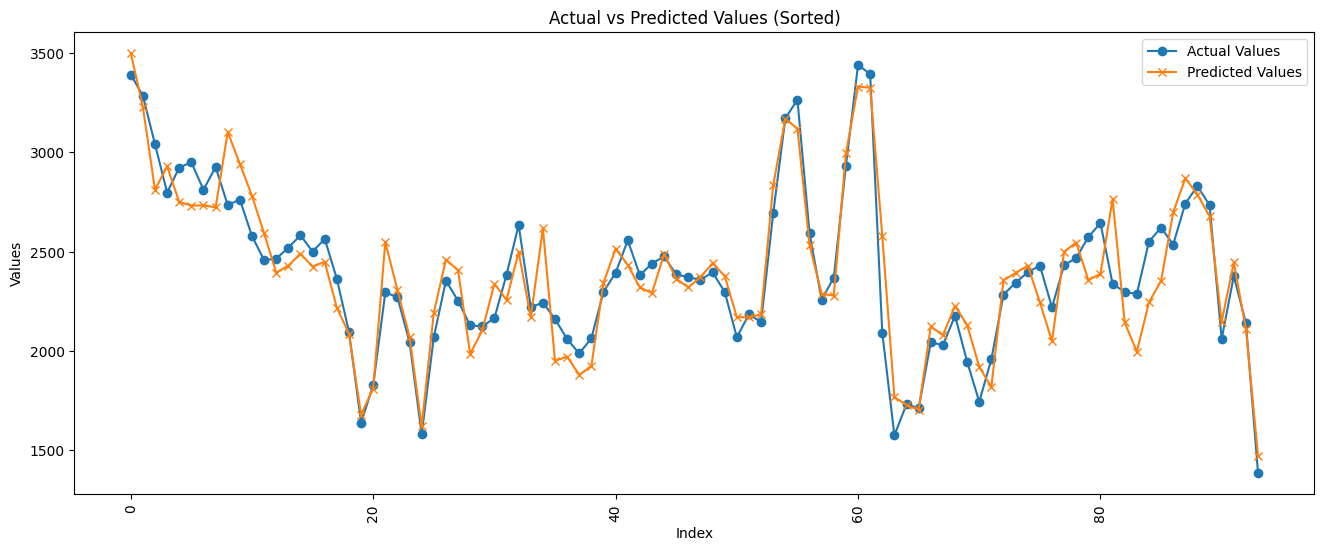

In [ ]:
plt.figure(figsize=(16, 6))
x_value = np.arange(len(Y))
plt.plot(x_value, Y, label='Actual Values', marker='o')
plt.plot(x_value, y_pred, label='Predicted Values', marker='x')

# Adding title and labels
plt.title('Actual vs Predicted Values (Sorted)')
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation = 90)
plt.legend()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Fit a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, Y)

# Make predictions
y_pred = model.predict(X)

# Calculate MAPE
mape = mean_absolute_percentage_error(Y, y_pred)
print('MAPE:', mape * 100, '%')


MAPE: 2.5218589343761773 %


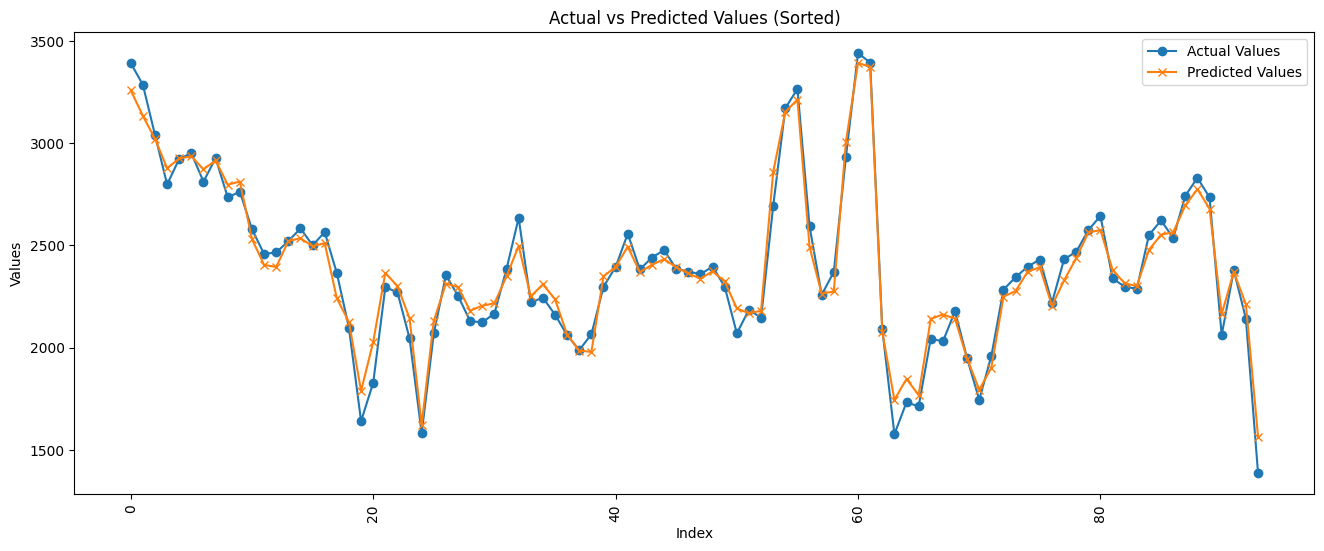

In [ ]:
plt.figure(figsize=(16, 6))
x_value = np.arange(len(Y))
plt.plot(x_value, Y, label='Actual Values', marker='o')
plt.plot(x_value, y_pred, label='Predicted Values', marker='x')

# Adding title and labels
plt.title('Actual vs Predicted Values (Sorted)')
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation = 90)
plt.legend()
plt.show()

In [ ]:
from xgboost import XGBRegressor

# Fit an XGBoost model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X, Y)

# Make predictions
y_pred = model.predict(X)

# Calculate MAPE
mape = mean_absolute_percentage_error(Y, y_pred)
print('MAPE:', mape * 100, '%')



MAPE: 0.27729727758157 %


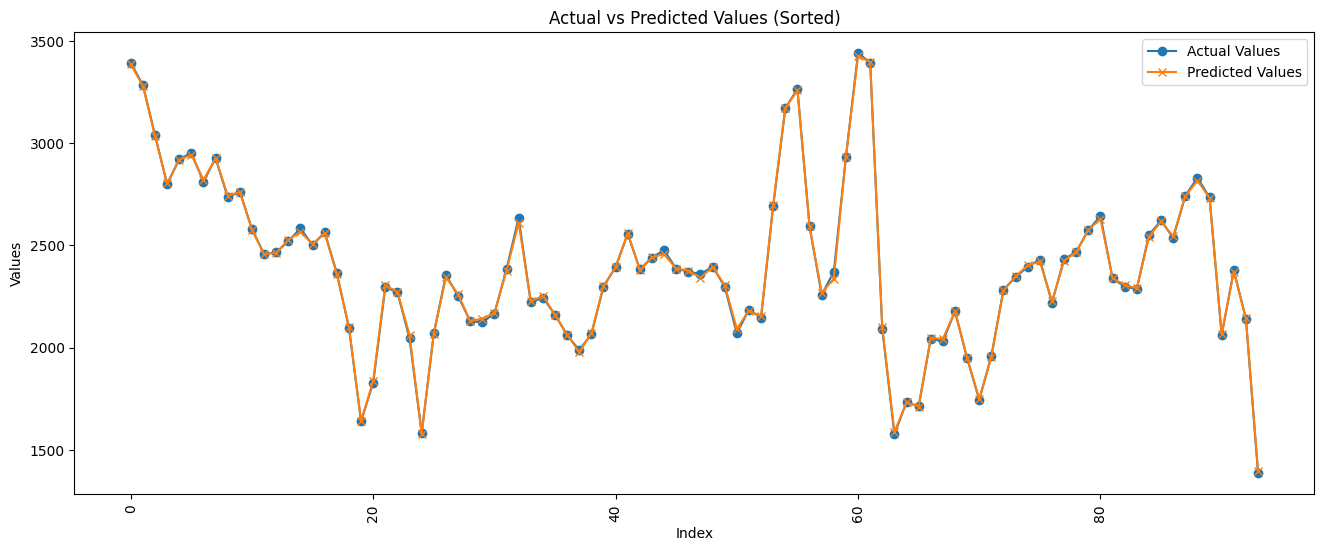

In [ ]:
plt.figure(figsize=(16, 6))
x_value = np.arange(len(Y))
plt.plot(x_value, Y, label='Actual Values', marker='o')
plt.plot(x_value, y_pred, label='Predicted Values', marker='x')

# Adding title and labels
plt.title('Actual vs Predicted Values (Sorted)')
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation = 90)
plt.legend()
plt.show()